# Dataset 3 — NHANES (Body Measures / Medidas Corporales)

## Descripción general
El **NHANES (National Health and Nutrition Examination Survey)** es un programa de estudios diseñado por el Centro para el Control y la Prevención de Enfermedades (CDC) de Estados Unidos. Combina entrevistas y exámenes físicos para evaluar la salud de la población. Para este trabajo se utilizó el archivo de exámenes físicos `BMX_L.xpt` (Body Measures), el cual contiene mediciones antropométricas detalladas como peso, altura, longitudes de extremidades y circunferencias corporales.

## Objetivo
**Problema de Regresión Múltiple** — predecir el peso corporal exacto de un paciente en kilogramos (variable objetivo: `BMXWT`), utilizando de forma combinada el resto de sus proporciones y medidas físicas (altura, circunferencias, etc.).

## Estructura original
- **Formato de origen:** Archivo estadístico SAS (`.xpt`).
- **Naturaleza de los datos:** Principalmente variables numéricas continuas (medidas en centímetros, milímetros y kilogramos).
- **Variable objetivo:** `BMXWT` (Weight in kg).

## Tipos de columnas
| Tipo | Ejemplos |
|------|---------|
| Identificadores (descartados) | `SEQN` (Sequence Number - ID único del paciente) |
| Metadatos/Comentarios (descartados) | Columnas que inician con `BMI` o `BMD` (códigos de estado del examen) |
| Predictoras numéricas (conservadas) | `BMXHT` (Altura), `BMXWAIST` (Cintura), `BMXARML` (Longitud del brazo) |
| Variable Objetivo | `BMXWT` (Peso del paciente) |

## Tratamiento aplicado

### 1. Decodificación y Filtrado Inicial
Al provenir de un formato `.xpt`, los datos de texto se decodificaron de *bytes* a *utf-8*. Posteriormente, **se eliminaron todas las filas que no tenían un peso registrado (`NaN` en `BMXWT`)**. En Machine Learning supervisado, no se puede entrenar a un modelo para predecir una variable objetivo si esta falta de origen.

### 2. Eliminación de columnas inútiles y metadatos
Se descartó la columna `SEQN` (Identificador del paciente) ya que no posee relación matemática con el peso. Además, se filtraron todas las columnas que inician con `BMI` o `BMD`, las cuales en la documentación de NHANES representan "comentarios del examinador" o "banderas de estado" (ej. si el paciente traía ropa pesada), lo cual introduce ruido innecesario al modelo matemático.

### 3. Eliminación de columnas con >50% de NaN
Se estableció un umbral estricto para eliminar cualquier medición corporal que faltara en más de la mitad de los pacientes (por ejemplo, mediciones altamente específicas que solo se le hacen a ciertos grupos de edad).

### 4. Imputación de NaN restantes
- **Columnas numéricas:** Las mediciones faltantes en pacientes individuales se imputaron utilizando la **mediana** de su respectiva columna, evitando que estaturas o medidas atípicas (outliers) sesgaran el reemplazo.
- **Columnas de texto:** Si existiera alguna, se imputó con la etiqueta `'Desconocido'`.

### 5. Justificación de OMITIR el Balanceo de Clases
A diferencia de los problemas de clasificación, **este dataset NO fue balanceado**. El objetivo es predecir una variable continua (el peso abarca un espectro infinito de números reales, ej. 50.5 kg, 80.2 kg). Las técnicas de balanceo (Undersampling/Oversampling) son matemáticamente incompatibles con la Regresión, ya que no existen "clases" discretas que igualar. Se mantuvo la distribución natural sesgada del peso de la población.

### 6. División de los datos (Train/Test Split)
Antes de dividir, **se desordenaron las filas aleatoriamente** (`np.random.permutation`) para destruir cualquier sesgo provocado por el orden en que los pacientes fueron registrados en el hospital. Luego se separó en:
- **Datos de Entrenamiento (80%):** Para el cálculo de los pesos (Thetas) mediante Descenso de Gradiente.
- **Datos de Prueba (20%):** Para medir el Error Cuadrático Medio (MSE) final del modelo.

### 7. Normalización (Estandarización Z-Score)
Paso crítico para este dataset, ya que combina medidas en milímetros (ej. pliegues cutáneos) con medidas en centímetros (ej. altura). Sin normalizar, el algoritmo le daría falsamente mayor importancia a la altura simplemente por tener un número más grande.
- Se calculó la media ($\mu$) y la desviación estándar ($\sigma$) **exclusivamente con el 80% de entrenamiento** para evitar la fuga de datos (Data Leakage) hacia el conjunto de prueba.
- Se añadió una columna inicial de unos (1) a las matrices $X$ para habilitar el cálculo de la intersección o término de sesgo ($\theta_0$).

## Resultado final
| | Descripción |
|--|---------|
| Problema a resolver | Regresión Múltiple Continua |
| Valores faltantes tras limpieza | 0 (Totalmente imputados) |
| Balanceo | No aplica (Variable Continua) |
| Preparación matemática | Matrices divididas 80/20, estandarizadas y con columna de sesgo añadida. |

Leyendo archivo SAS (.xpt)... esto puede tardar unos segundos.
Shape original: (8860, 22)
Shape tras eliminar pacientes sin peso registrado: (8754, 22)

Shape después de eliminar identificadores y metadatos: (8754, 10)

Columnas eliminadas por tener >50% de NaN:
  BMXRECUM: 94.8% nulos
  BMXHEAD: 99.2% nulos

NaN numéricos imputados con la mediana de cada columna.
NaN restantes totales: 0

 OMITIDO: BALANCEO DE CLASES 
Este es un problema de REGRESIÓN (predecir peso en kg).
El balanceo solo aplica para clasificación. Continuamos...

 DESCRIPCIÓN DEL DATASET PREPARADO 
Nombre: NHANES - Body Measures (BMX_L)
Problema: Regresión Múltiple — predecir el peso corporal (kg)
Filas listas: 8754
Columnas predictoras: 7
Variable objetivo: BMXWT (Peso en kg)
Rango de peso: 2.7 kg - 248.2 kg
NaN restantes: 0

Dataset guardado como 'NHANES_preparado.csv'

 INICIANDO DIVISIÓN 80/20 Y NORMALIZACIÓN
Variables en memoria listas para el algoritmo matemático
Tamaño X_train_norm: (7003, 8)
Tamaño y_train: 

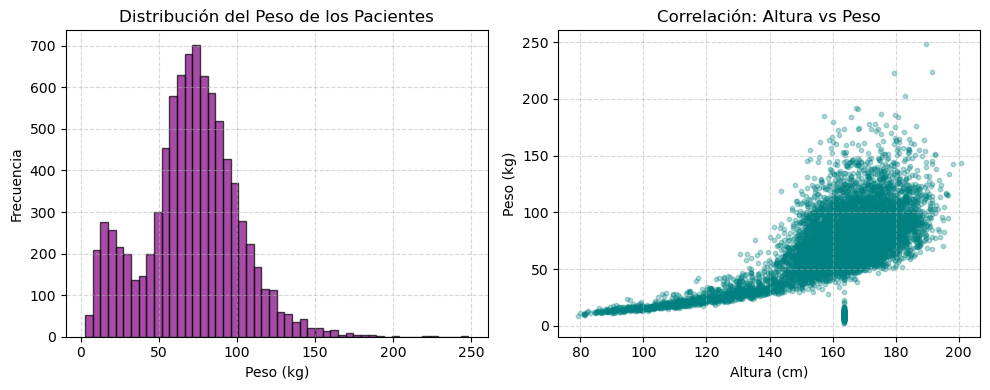

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PREPARACIÓN DATASET 3: NHANES (Regresión)

# 1. CARGAR
ruta_nhanes = r'C:\Users\Usuario\Documents\7mo semestre\Sis420\PrimerParcial\Dataset3\BMX_L.xpt'

print("Leyendo archivo SAS (.xpt)... esto puede tardar unos segundos.")
df = pd.read_sas(ruta_nhanes)

# Los archivos SAS a veces leen los textos como "bytes". Esto lo soluciona:
for col in df.select_dtypes(include='object').columns:
    try:
        df[col] = df[col].str.decode('utf-8')
    except:
        pass

print("Shape original:", df.shape)

# Vamos a predecir el Peso (BMXWT - Weight in kg)
# Primero, eliminamos las filas donde no registraron el peso (no podemos entrenar sin la respuesta)
df = df.dropna(subset=['BMXWT'])
print(f"Shape tras eliminar pacientes sin peso registrado: {df.shape}")

# 2. ELIMINAR COLUMNAS INÚTILES
# Eliminamos SEQN (ID del paciente) y las columnas de comentarios que empiezan con 'BMI' o 'BMD'
cols_a_eliminar = ['SEQN'] + [c for c in df.columns if c.startswith('BMI') or c.startswith('BMD')]
cols_a_eliminar = [c for c in cols_a_eliminar if c in df.columns]
df = df.drop(columns=cols_a_eliminar)
print("\nShape después de eliminar identificadores y metadatos:", df.shape)

# 3. ELIMINAR COLUMNAS CON >50% DE NaN
umbral = 0.5 * len(df)
cols_muchos_nulos = df.columns[df.isnull().sum() > umbral].tolist()
print("\nColumnas eliminadas por tener >50% de NaN:")
if cols_muchos_nulos:
    for col in cols_muchos_nulos:
        pct = df[col].isnull().sum() / len(df) * 100
        print(f"  {col}: {pct:.1f}% nulos")
else:
    print("  Ninguna columna superó el 50% de nulos.")
df = df.drop(columns=cols_muchos_nulos)

# 4. IMPUTAR NaN RESTANTES
cols_numericas = df.select_dtypes(include=['float64', 'int64']).columns
for col in cols_numericas:
    if col == 'BMXWT':
        continue
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)
        # Comentamos el print para no llenar la pantalla de texto, pero sí se imputan
        # print(f"  {col}: NaN imputados con mediana ({mediana})")
print("\nNaN numéricos imputados con la mediana de cada columna.")

cols_texto = df.select_dtypes(include='object').columns
for col in cols_texto:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna('Desconocido')

print("NaN restantes totales:", df.isnull().sum().sum())

# 5. ONE-HOT ENCODING (Solo si quedara alguna variable de texto)
if len(cols_texto) > 0:
    df = pd.get_dummies(df, columns=cols_texto.tolist())
    print("Shape después de one-hot encoding:", df.shape)

# 6. BALANCEAR CLASES
print("\n OMITIDO: BALANCEO DE CLASES ")
print("Este es un problema de REGRESIÓN (predecir peso en kg).")
print("El balanceo solo aplica para clasificación. Continuamos...\n")

# 7. MOVER TARGET (BMXWT) AL FINAL
cols = [c for c in df.columns if c != 'BMXWT'] + ['BMXWT']
df = df[cols]

# 8. RESUMEN FINAL
print(" DESCRIPCIÓN DEL DATASET PREPARADO ")
print(f"Nombre: NHANES - Body Measures (BMX_L)")
print(f"Problema: Regresión Múltiple — predecir el peso corporal (kg)")
print(f"Filas listas: {df.shape[0]}")
print(f"Columnas predictoras: {df.shape[1] - 1}")
print(f"Variable objetivo: BMXWT (Peso en kg)")
print(f"Rango de peso: {df['BMXWT'].min()} kg - {df['BMXWT'].max()} kg")
print(f"NaN restantes: {df.isnull().sum().sum()}")

# 9. GUARDAR EL CSV COMO RESPALDO
# Lo guardamos en formato CSV estándar para que mañana sea más fácil de leer
df.to_csv('NHANES_preparado.csv', index=False)
print("\nDataset guardado como 'NHANES_preparado.csv'")


# DIVISIÓN 80/20 Y NORMALIZACIÓN MATEMÁTICA
print("\n INICIANDO DIVISIÓN 80/20 Y NORMALIZACIÓN")

# Separar características (X) y la variable objetivo (y)
X = df.drop('BMXWT', axis=1).values
y = df['BMXWT'].values

# Calcular el índice de corte para el 80%
m = len(y)
limite = int(m * 0.8)

# Desordenar los datos antes de dividir (importante para evitar sesgos por orden de pacientes)
np.random.seed(42)
indices = np.random.permutation(m)
X = X[indices]
y = y[indices]

# División 80/20
X_train, X_test = X[:limite], X[limite:]
y_train, y_test = y[:limite], y[limite:]

# Función manual para Normalizar (Estandarización)
def normalizar(X_data):
    mu = np.mean(X_data, axis=0)
    sigma = np.std(X_data, axis=0)
    # Evitar divisiones por cero
    sigma[sigma == 0] = 1 
    X_norm = (X_data - mu) / sigma
    return X_norm, mu, sigma

# Normalizamos usando SOLO los datos de entrenamiento
X_train_norm, mu, sigma = normalizar(X_train)
X_test_norm = (X_test - mu) / sigma

# Agregar la columna de unos (Término de sesgo/Intercepto) a ambos conjuntos
X_train_norm = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_norm = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print("Variables en memoria listas para el algoritmo matemático")
print(f"Tamaño X_train_norm: {X_train_norm.shape}")
print(f"Tamaño y_train:      {y_train.shape}")
print(f"Tamaño X_test_norm:  {X_test_norm.shape}")

# 10. GRÁFICAS PARA REGRESIÓN
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['BMXWT'], bins=50, color='purple', edgecolor='black', alpha=0.7)
plt.title("Distribución del Peso de los Pacientes")
plt.xlabel("Peso (kg)")
plt.ylabel("Frecuencia")
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
# Si BMXHT (Altura) existe, la graficamos contra el peso
if 'BMXHT' in df.columns:
    plt.scatter(df['BMXHT'], df['BMXWT'], alpha=0.3, color='teal', s=10)
    plt.title("Correlación: Altura vs Peso")
    plt.xlabel("Altura (cm)")
    plt.ylabel("Peso (kg)")
else:
    plt.boxplot(df['BMXWT'])
    plt.title("Dispersión del Peso (Boxplot)")
    
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()